In [139]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np


In [140]:
# ---------- Load actual seasonal extrapolation results ----------
xlsx_path = "../Table/Extended Data Table 1 (Seasonal extrapolation test).xlsx"
seasons = ["2023NH", "2023SH", "2024NH", "2024SH", "2025NH", "2025SH"]
metrics = ["MAE", "MSE", "Pearson", "Spearman", "R2"]

# Display order chosen to match the intended main-message emphasis
models = ["fluAgPredictor", "Adaboost", "vaxseer", "Nextflu"]
display_names = {
    "fluAgPredictor": "fluAgPredictor",
    "Adaboost": "AdaBoost",
    "vaxseer": "vaxseer",
    "Nextflu": "Nextflu",
}

higher_better = {"Pearson", "Spearman", "R2"}



rows = []
for season in seasons:
    df = pd.read_excel(xlsx_path, sheet_name=season)
    df = df[["target", "fluAgPredictor", "Adaboost", "vaxseer", "Nextflu"]]
    for _, row in df.iterrows():
        metric = row["target"]
        values = row.drop("target")
        ascending = metric not in higher_better
        ranks = values.rank(method="min", ascending=ascending).astype(int)
        for model in models:
            rows.append({
                "season": season,
                "metric": metric,
                "model": model,
                "value": float(values[model]),
                "rank": int(ranks[model]),
            })

rank_df = pd.DataFrame(rows)

summary = (
    rank_df.groupby("model")["rank"]
    .agg(mean_rank="mean", top2=lambda x: int((x <= 2).sum()))
    .reset_index()
)
summary["mean_rank"] = summary["mean_rank"].round(2)

mean_rank = {r["model"]: r["mean_rank"] for _, r in summary.iterrows()}
top2 = {r["model"]: r["top2"] for _, r in summary.iterrows()}

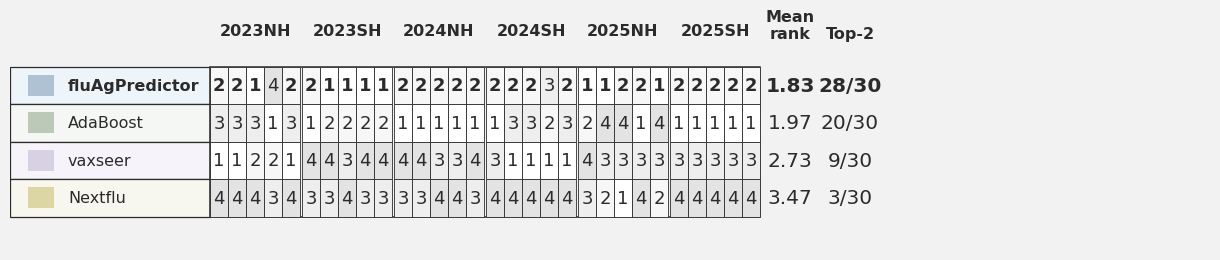

../Figure/Fig2E.svg


In [141]:
# --- Centralized configuration (edit here only) ---
default_config = {
    "colors": {
        "bg": "#f2f2f2",
        "line": "#2b2b2b",
        "highlight": "#e53935",
        "model_colors": {
            "fluAgPredictor": "#aec2d3",
            "Nextflu": "#dcd6a5",
            "Adaboost": "#bcc8b8",
            "vaxseer": "#d8d1e4",
        },
        "row_tints": {
            "fluAgPredictor": "#edf4fa",
            "Adaboost": "#f5f7f4",
            "vaxseer": "#f6f4fa",
            "Nextflu": "#f8f7ef",
        },
        "rank_fill": {
            1: "#ffffff",
            2: "#f7f7f7",
            3: "#eeeeee",
            4: "#e3e3e3",
        },
    },
    "layout": {
        "fig_size": (12, 2.0),
        "ax_limits": (0, 12, 1.2, 6.0),
        "left": 0,
        "bottom": 2.0,
        "label_w": 2,
        "cell_w": 0.18,
        "cell_h": 0.90,
        "season_gap": 0.02,
        "summary_gap": -0.2,
        "summary_w": 1,
        "summary_col_gap": -0.4,
    },
    "text": {
        "model_name_x_offset": 0.58,
        "model_name_fontsize": 11.5,
        "season_fontsize": 11.5,
        "header_fontsize": 11.5,
        "rank_fontsize": 13,
        "summary_fontsize": 14.5,
    },
}


def plot_fig2E(rank_df, mean_rank, top2, models, seasons, metrics, display_names,
               config, out_path="../Figure/Fig2E.svg"):

    CONFIG = config
    # unpack for concise downstream drawing code
    BG_COLOR = CONFIG["colors"]["bg"]
    LINE_COLOR = CONFIG["colors"]["line"]
    HIGHLIGHT_COLOR = CONFIG["colors"]["highlight"]
    model_colors = CONFIG["colors"]["model_colors"]
    row_tints = CONFIG["colors"]["row_tints"]
    rank_fill = CONFIG["colors"]["rank_fill"]

    FIG_SIZE = CONFIG["layout"]["fig_size"]
    AX_LIMITS = CONFIG["layout"]["ax_limits"]
    LEFT = CONFIG["layout"]["left"]
    BOTTOM = CONFIG["layout"]["bottom"]
    LABEL_W = CONFIG["layout"]["label_w"]
    CELL_W = CONFIG["layout"]["cell_w"]
    CELL_H = CONFIG["layout"]["cell_h"]
    SEASON_GAP = CONFIG["layout"]["season_gap"]

    # --- Helper drawing functions ---
    def draw_row_labels(ax):
        for i, model in enumerate(models):
            y = BOTTOM + (len(models) - 1 - i) * CELL_H
            # 恢复 model 行的底色矩形 + 左侧小色块
            ax.add_patch(
                Rectangle(
                    (LEFT, y), LABEL_W, CELL_H,
                    facecolor=row_tints[model], edgecolor=LINE_COLOR, linewidth=0.9,
                )
            )
            ax.add_patch(
                Rectangle(
                    (LEFT + 0.18, y + 0.20), 0.26, 0.50,
                    facecolor=model_colors[model], edgecolor="none",
                )
            )
            ax.text(
                LEFT + CONFIG["text"]["model_name_x_offset"],
                y + CELL_H / 2,
                display_names[model],
                fontsize=CONFIG["text"]["model_name_fontsize"],
                ha="left",
                va="center",
                fontweight="bold" if model == "fluAgPredictor" else None,
                color=LINE_COLOR,
            )

    def draw_season_block(ax, season, season_index):
        season_x = LEFT + LABEL_W + season_index * (len(metrics) * CELL_W + SEASON_GAP)

        # season header（不再画外框，只保留文字）
        ax.text(
            season_x + 2.5 * CELL_W,
            BOTTOM + len(models) * CELL_H + 0.68,
            season,
            fontsize=CONFIG["text"]["season_fontsize"],
            fontweight="bold",
            ha="center",
            va="bottom",
            color=LINE_COLOR,
        )

        # cells (metric headers omitted; order given in panel text)
        for mi, metric in enumerate(metrics):
            cx = season_x + mi * CELL_W
            for ri, model in enumerate(models):
                y = BOTTOM + (len(models) - 1 - ri) * CELL_H
                rank = int(
                    rank_df[
                        (rank_df["season"] == season)
                        & (rank_df["metric"] == metric)
                        & (rank_df["model"] == model)
                    ]["rank"].iloc[0]
                )
                ax.add_patch(
                    Rectangle(
                        (cx, y), CELL_W, CELL_H,
                        facecolor=rank_fill[rank],
                        edgecolor=LINE_COLOR,
                        linewidth=0.6,
                    )
                )
                ax.text(
                    cx + CELL_W / 2,
                    y + CELL_H / 2,
                    str(rank),
                    fontsize=CONFIG["text"]["rank_fontsize"],
                    ha="center",
                    va="center",
                    fontweight="bold" if (model == "fluAgPredictor" and rank in [1, 2]) else None,
                    color=LINE_COLOR,
                )

    def draw_summary_blocks(ax):
        table_w = len(seasons) * len(metrics) * CELL_W + (len(seasons) - 1) * SEASON_GAP
        table_h = len(models) * CELL_H

        gap = CONFIG["layout"]["summary_gap"]
        sum1_x = LEFT + LABEL_W + table_w + gap
        sum_w = CONFIG["layout"]["summary_w"]
        sum_gap = CONFIG["layout"]["summary_col_gap"]
        sum2_x = sum1_x + sum_w + sum_gap

        ax.text(
            sum1_x + sum_w / 2,
            BOTTOM + table_h + 0.60,
            "Mean\nrank",
            fontsize=CONFIG["text"]["header_fontsize"],
            fontweight="bold",
            ha="center",
            va="bottom",
            color=LINE_COLOR,
        )
        ax.text(
            sum2_x + sum_w / 2,
            BOTTOM + table_h + 0.60,
            "Top-2",
            fontsize=CONFIG["text"]["header_fontsize"],
            fontweight="bold",
            ha="center",
            va="bottom",
            color=LINE_COLOR,
        )

        for i, model in enumerate(models):
            y = BOTTOM + (len(models) - 1 - i) * CELL_H
            # 不再为 Mean rank 或 Top-2 画任何矩形，只保留数字文字

            ax.text(
                sum1_x + sum_w / 2,
                y + CELL_H / 2,
                f"{mean_rank[model]:.2f}",
                fontsize=CONFIG["text"]["summary_fontsize"],
                ha="center",
                va="center",
                fontweight="bold" if model == "fluAgPredictor" else None,
                color=LINE_COLOR,
            )
            ax.text(
                sum2_x + sum_w / 2,
                y + CELL_H / 2,
                f"{top2[model]}/30",
                fontsize=CONFIG["text"]["summary_fontsize"],
                ha="center",
                va="center",
                fontweight="bold" if model == "fluAgPredictor" else None,
                color=LINE_COLOR,
            )

    # --- Main figure ---
    fig = plt.figure(figsize=FIG_SIZE, facecolor=BG_COLOR)
    ax = plt.axes([0, 0, 1, 1], facecolor=BG_COLOR)
    ax.set_xlim(AX_LIMITS[0], AX_LIMITS[1])
    ax.set_ylim(AX_LIMITS[2], AX_LIMITS[3])
    ax.axis("off")

    # Row labels and main table frame
    n_rows = len(models)
    table_h = n_rows * CELL_H
    draw_row_labels(ax)

    n_cols = len(seasons) * len(metrics)
    table_w = n_cols * CELL_W + (len(seasons) - 1) * SEASON_GAP
    table_x = LEFT + LABEL_W
    ax.add_patch(
        Rectangle(
            (table_x, BOTTOM), table_w, table_h,
            facecolor="none", edgecolor=LINE_COLOR, linewidth=1.1,
        )
    )

    # All seasons
    for si, season in enumerate(seasons):
        draw_season_block(ax, season, si)

    # Summary blocks on the right
    draw_summary_blocks(ax)

    # Save output (transparent background)
    plt.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.0, facecolor="none")
    plt.show()

    print(out_path)


# actually draw the figure (use default_config)
plot_fig2E(rank_df, mean_rank, top2, models, seasons, metrics, display_names, default_config)